# Analyse du corpus politique français
Analyse statistique et visuelle par orientation politique (Y) et par thème.

In [19]:
import json
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# Création dossier figures
os.makedirs('figures', exist_ok=True)

THEMES = ['securite', 'ecologie', 'economie', 'mobilite', 'education', 'sociale']
THEME_LABELS = {'securite':'Sécurité','ecologie':'Écologie','economie':'Économie',
                'mobilite':'Mobilité','education':'Éducation','sociale':'Social'}

LABEL_NAMES = {'ED':'Extrême droite','D':'Droite','C':'Centre','G':'Gauche','EG':'Extrême gauche'}
ORDER = ['EG', 'G', 'C', 'D', 'ED']

COLORS = {
    'ED': '#1a1a2e',
    'D':  '#1e6fd9',
    'C':  '#f5a623',
    'G':  '#e8453c',
    'EG': '#8B0000',
}

# Chargement unique
with open('data/corpus.json', encoding='utf-8') as f:
    all_docs = json.load(f)

print(f'Total documents chargés : {len(all_docs)}')
print(Counter(d['y'] for d in all_docs))

Total documents chargés : 51
Counter({'C': 12, 'EG': 11, 'ED': 10, 'D': 10, 'G': 8})


## 1. Construction du DataFrame

In [17]:
rows = []
for d in all_docs:
    themes = d.get('themes', {})
    non_classe = d.get('non_classe', '')
    theme_tokens = {t: len(themes.get(t, '').split()) for t in THEMES}
    total_tokens = sum(theme_tokens.values()) + len(non_classe.split())
    classified_tokens = sum(theme_tokens.values())
    row = {
        'id': d['id'],
        'y': d['y'],
        'source': d.get('source', ''),
        'parti': d.get('parti', 'N/A'),
        'candidat': d.get('candidat', 'N/A'),
        'total_tokens': total_tokens,
        'classified_tokens': classified_tokens,
        'non_classe_tokens': len(non_classe.split()),
        'coverage_pct': round(classified_tokens / total_tokens * 100, 1) if total_tokens > 0 else 0,
        **{f'tokens_{t}': theme_tokens[t] for t in THEMES}
    }
    rows.append(row)

df = pd.DataFrame(rows)
df['y'] = pd.Categorical(df['y'], categories=ORDER, ordered=True)
df['label'] = df['y'].map(LABEL_NAMES)
df = df.sort_values('y').reset_index(drop=True)

df[['y','label','parti','total_tokens','coverage_pct'] + [f'tokens_{t}' for t in THEMES]]

,y,label,parti,total_tokens,coverage_pct,tokens_securite,tokens_ecologie,tokens_economie,tokens_mobilite,tokens_education,tokens_sociale
0,EG,Extrême gauche,NPA,1355,85.5,249,94,491,67,21,236
1,EG,Extrême gauche,Lutte Ouvrière,731,87.1,170,0,197,17,0,253
2,EG,Extrême gauche,Lutte Ouvrière,734,87.2,173,0,197,17,0,253
3,EG,Extrême gauche,Lutte Ouvrière,1538,77.0,164,60,638,142,20,160
4,EG,Extrême gauche,Lutte Ouvrière,593,89.5,133,0,185,0,14,199
5,EG,Extrême gauche,La France Insoumise,556,77.7,56,77,77,61,41,120
6,EG,Extrême gauche,Lutte Ouvrière,597,89.4,133,0,207,0,0,194
7,EG,Extrême gauche,Lutte Ouvrière,593,89.5,133,0,185,0,14,199
8,EG,Extrême gauche,La France Insoumise,831,94.8,83,293,167,73,61,111
9,EG,Extrême gauche,La France Insoumise,1413,71.4,59,191,224,0,86,449


## 2. Taille du corpus

                nb_docs  total_tokens  moy_tokens  min_tokens  max_tokens  coverage_moy
Extrême gauche       11         10571       961.0         556        1630          80.4
Gauche                8         10314      1289.2         768        1988          72.3
Centre               12         10581       881.8           0        1452          61.0
Droite               10          8062       806.2           0        1431          67.7
Extrême droite       10          7419       741.9         229        1728          73.5


C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\3565530938.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels_plot, rotation=20, ha='right')
C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\3565530938.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels_plot, rotation=20, ha='right')
C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\3565530938.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(labels_plot, rotation=20, ha='right')


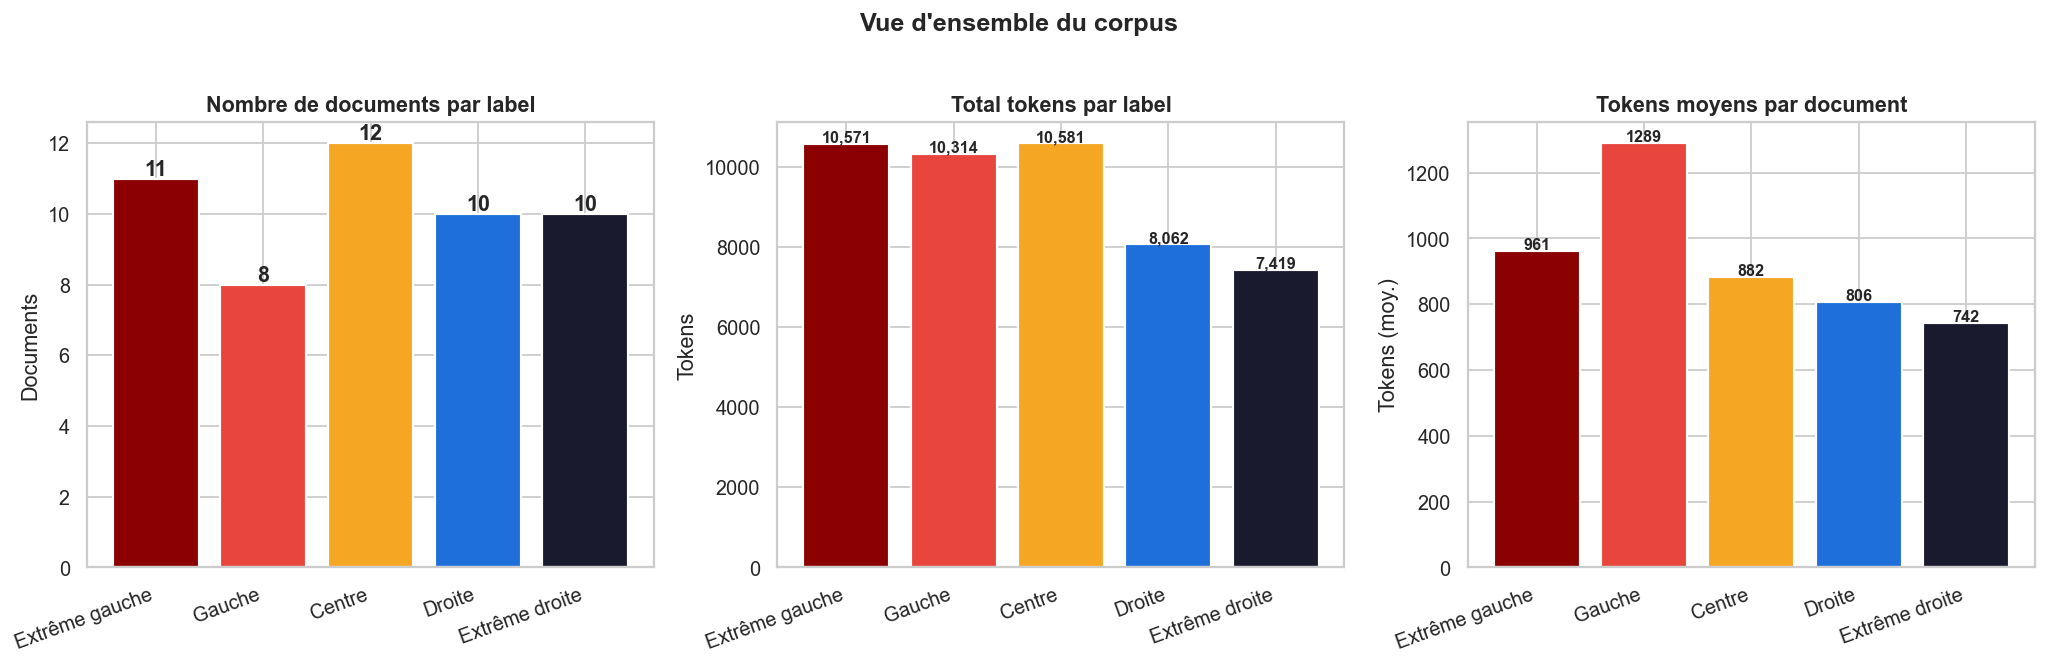

In [20]:
stats = df.groupby('y', observed=True).agg(
    nb_docs=('id', 'count'),
    total_tokens=('total_tokens', 'sum'),
    moy_tokens=('total_tokens', 'mean'),
    min_tokens=('total_tokens', 'min'),
    max_tokens=('total_tokens', 'max'),
    coverage_moy=('coverage_pct', 'mean'),
).round(1)
stats.index = [LABEL_NAMES[y] for y in stats.index]
print(stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_plot = stats.index.tolist()
colors_plot = [COLORS[y] for y in ORDER]

axes[0].bar(labels_plot, stats['nb_docs'], color=colors_plot, edgecolor='white', linewidth=1.2)
axes[0].set_title('Nombre de documents par label', fontweight='bold')
axes[0].set_ylabel('Documents')
for i, v in enumerate(stats['nb_docs']):
    axes[0].text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')
axes[0].set_xticklabels(labels_plot, rotation=20, ha='right')

axes[1].bar(labels_plot, stats['total_tokens'], color=colors_plot, edgecolor='white', linewidth=1.2)
axes[1].set_title('Total tokens par label', fontweight='bold')
axes[1].set_ylabel('Tokens')
for i, v in enumerate(stats['total_tokens']):
    axes[1].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticklabels(labels_plot, rotation=20, ha='right')

axes[2].bar(labels_plot, stats['moy_tokens'], color=colors_plot, edgecolor='white', linewidth=1.2)
axes[2].set_title('Tokens moyens par document', fontweight='bold')
axes[2].set_ylabel('Tokens (moy.)')
for i, v in enumerate(stats['moy_tokens']):
    axes[2].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticklabels(labels_plot, rotation=20, ha='right')

plt.suptitle("Vue d'ensemble du corpus", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/corpus_resume.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Distribution des tokens par document (boxplot)

C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\1052888818.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=10)


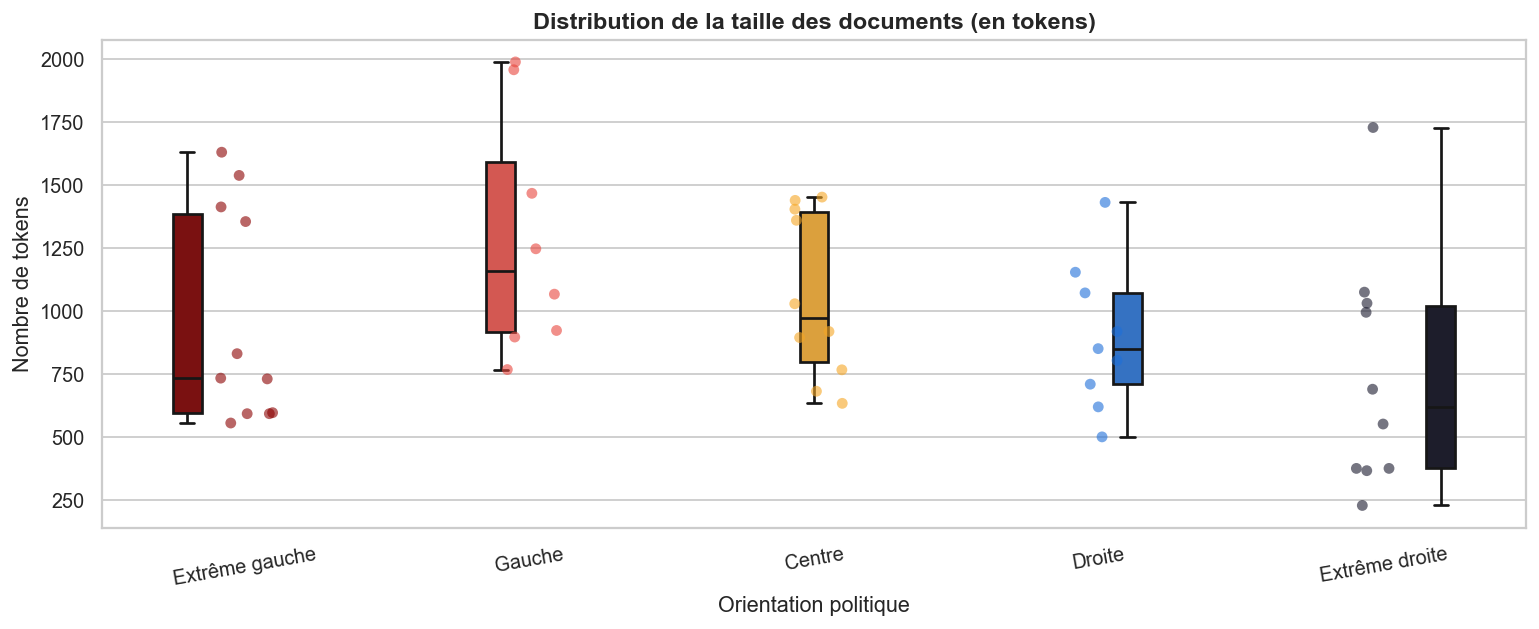

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

label_order = [LABEL_NAMES[y] for y in ORDER]
palette_names = {LABEL_NAMES[y]: COLORS[y] for y in ORDER}

df['label'] = pd.Categorical(df['label'], categories=label_order, ordered=True)

sns.boxplot(
    data=df[df['total_tokens'] > 0], x='label', y='total_tokens',
    order=label_order, palette=palette_names, hue='label', legend=False,
    width=0.5, linewidth=1.5, ax=ax
)
sns.stripplot(
    data=df[df['total_tokens'] > 0], x='label', y='total_tokens',
    order=label_order, palette=palette_names, hue='label', legend=False,
    alpha=0.6, jitter=True, size=6, ax=ax
)

ax.set_title('Distribution de la taille des documents (en tokens)', fontsize=13, fontweight='bold')
ax.set_xlabel('Orientation politique')
ax.set_ylabel('Nombre de tokens')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
plt.tight_layout()
plt.savefig('figures/tokens_distribution_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Répartition thématique par label (stacked bar)

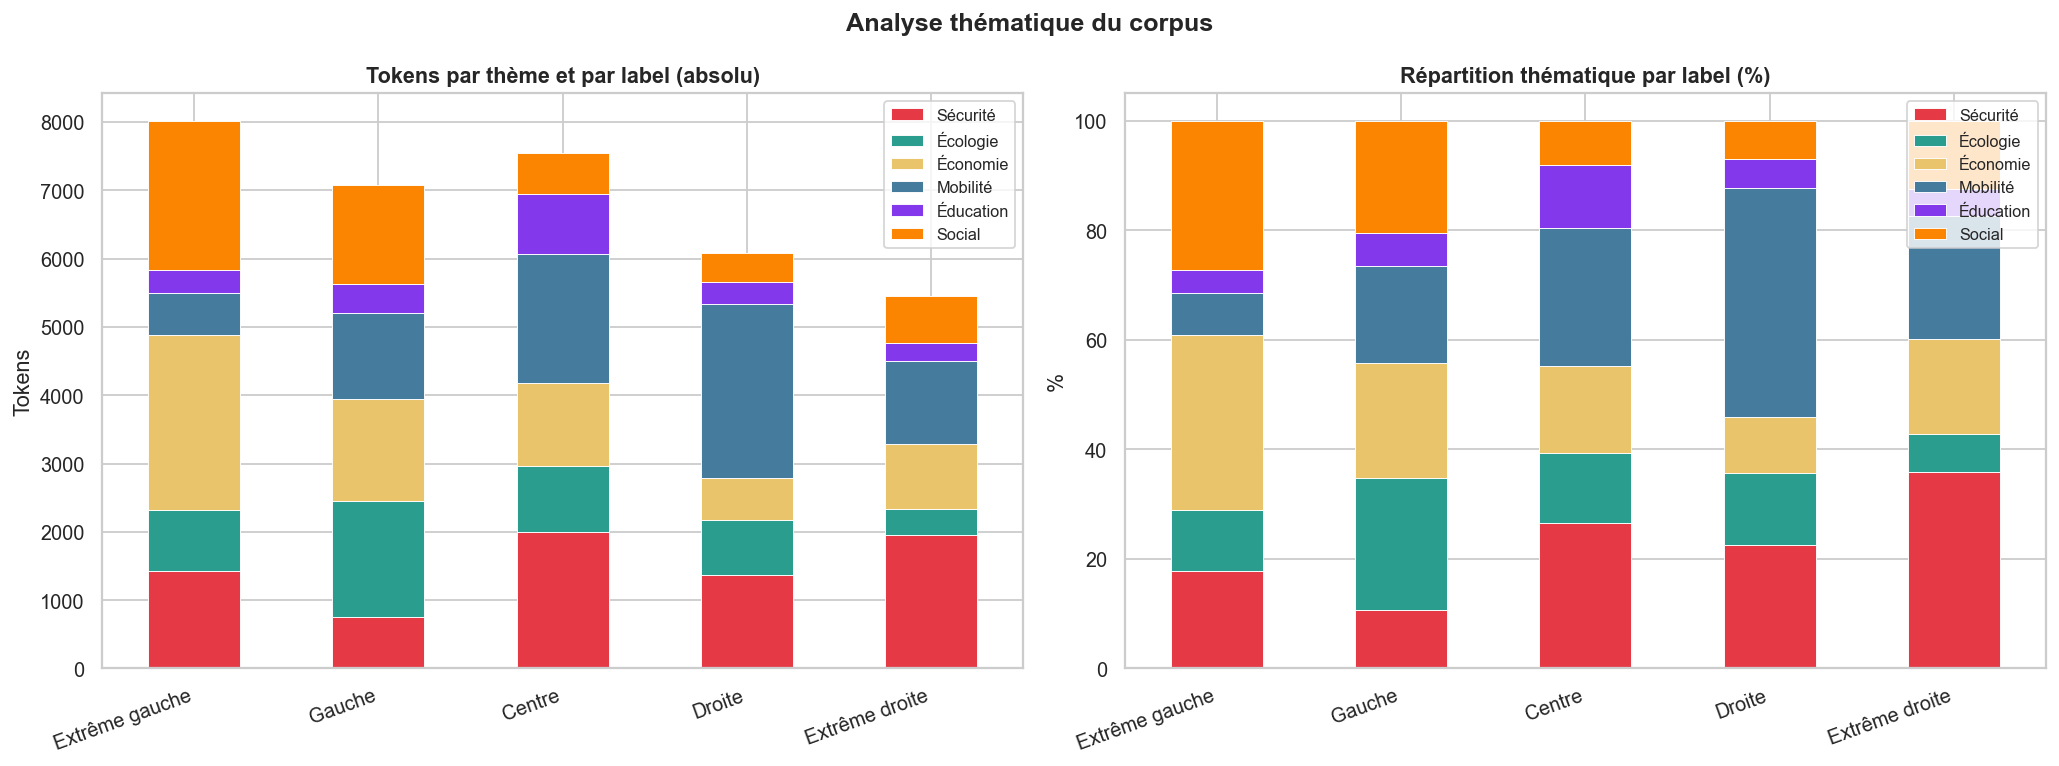

                Sécurité  Écologie  Économie  Mobilité  Éducation  Social
Extrême gauche      17.9      11.1      32.0       7.5        4.3    27.3
Gauche              10.7      24.0      21.1      17.7        6.0    20.6
Centre              26.5      12.8      16.0      25.1       11.6     8.1
Droite              22.5      13.1      10.2      41.9        5.3     7.0
Extrême droite      35.8       7.0      17.3      22.4        4.8    12.6


In [22]:
theme_cols = [f'tokens_{t}' for t in THEMES]
theme_by_label = df.groupby('y', observed=True)[theme_cols].sum()
theme_by_label.index = [LABEL_NAMES[y] for y in theme_by_label.index]
theme_by_label.columns = [THEME_LABELS[t] for t in THEMES]

theme_pct = theme_by_label.div(theme_by_label.sum(axis=1), axis=0) * 100

THEME_COLORS = ['#e63946','#2a9d8f','#e9c46a','#457b9d','#8338ec','#fb8500']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

theme_by_label.plot(kind='bar', stacked=True, ax=axes[0], color=THEME_COLORS,
                    edgecolor='white', linewidth=0.5)
axes[0].set_title('Tokens par thème et par label (absolu)', fontweight='bold')
axes[0].set_ylabel('Tokens')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].legend(loc='upper right', fontsize=9)

theme_pct.plot(kind='bar', stacked=True, ax=axes[1], color=THEME_COLORS,
               edgecolor='white', linewidth=0.5)
axes[1].set_title('Répartition thématique par label (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Analyse thématique du corpus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/thematique.png', dpi=130, bbox_inches='tight')
plt.show()

print(theme_pct.round(1).to_string())

## 5. Heatmap thèmes × labels

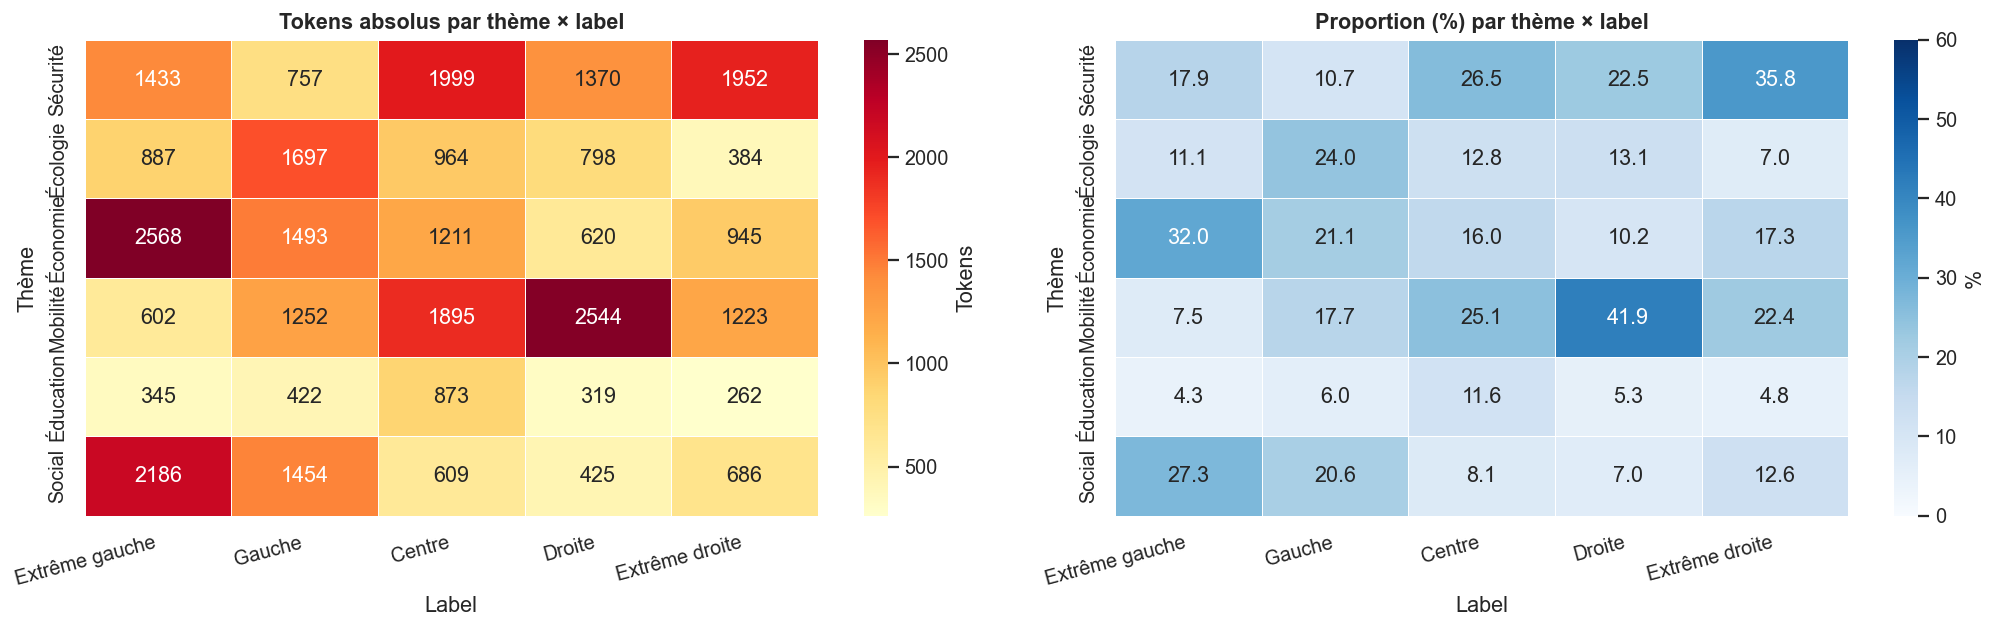

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap tokens absolus
sns.heatmap(
    theme_by_label.T, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Tokens'}
)
axes[0].set_title('Tokens absolus par thème × label', fontweight='bold')
axes[0].set_ylabel('Thème')
axes[0].set_xlabel('Label')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Heatmap %
sns.heatmap(
    theme_pct.T, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': '%'}, vmin=0, vmax=60
)
axes[1].set_title('Proportion (%) par thème × label', fontweight='bold')
axes[1].set_ylabel('Thème')
axes[1].set_xlabel('Label')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('figures/theme_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Radar chart — profil thématique par label

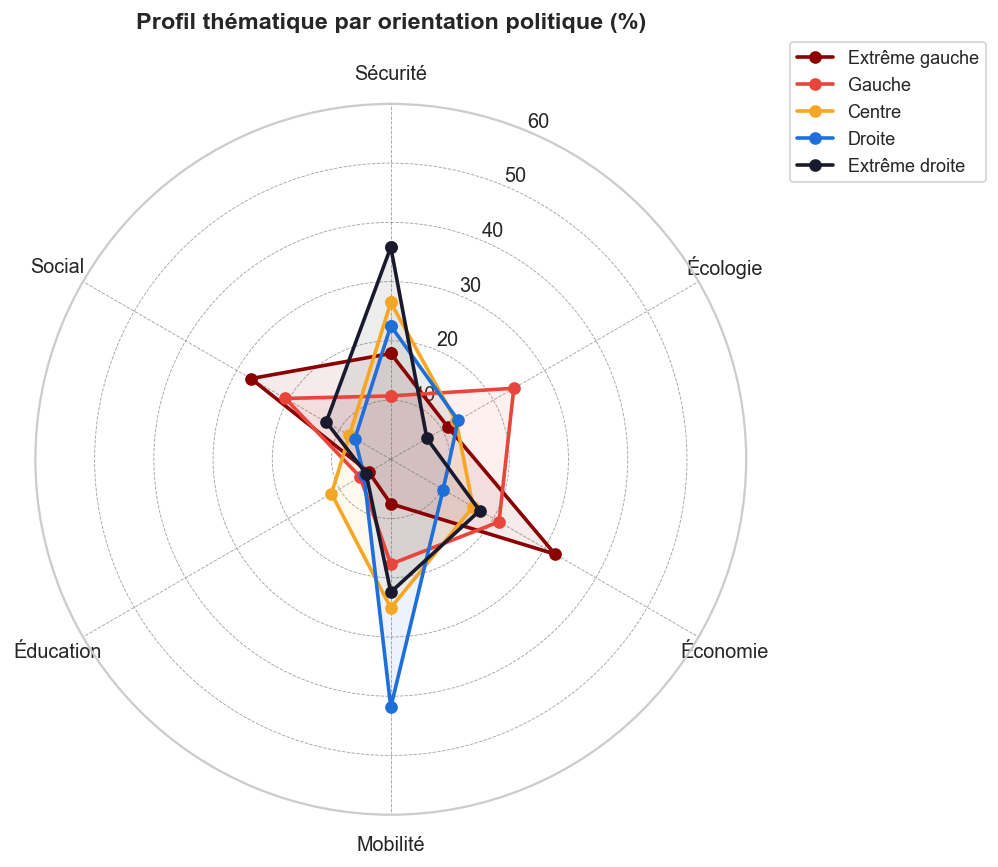

In [24]:
theme_names = list(THEME_LABELS.values())
N = len(theme_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for y in ORDER:
    label_name = LABEL_NAMES[y]
    if label_name not in theme_pct.index:
        continue
    values = theme_pct.loc[label_name].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=label_name, color=COLORS[y])
    ax.fill(angles, values, alpha=0.08, color=COLORS[y])

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), theme_names, fontsize=11)
ax.set_ylim(0, 60)
ax.set_title('Profil thématique par orientation politique (%)', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('figures/thematique_radar.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Taux de couverture thématique

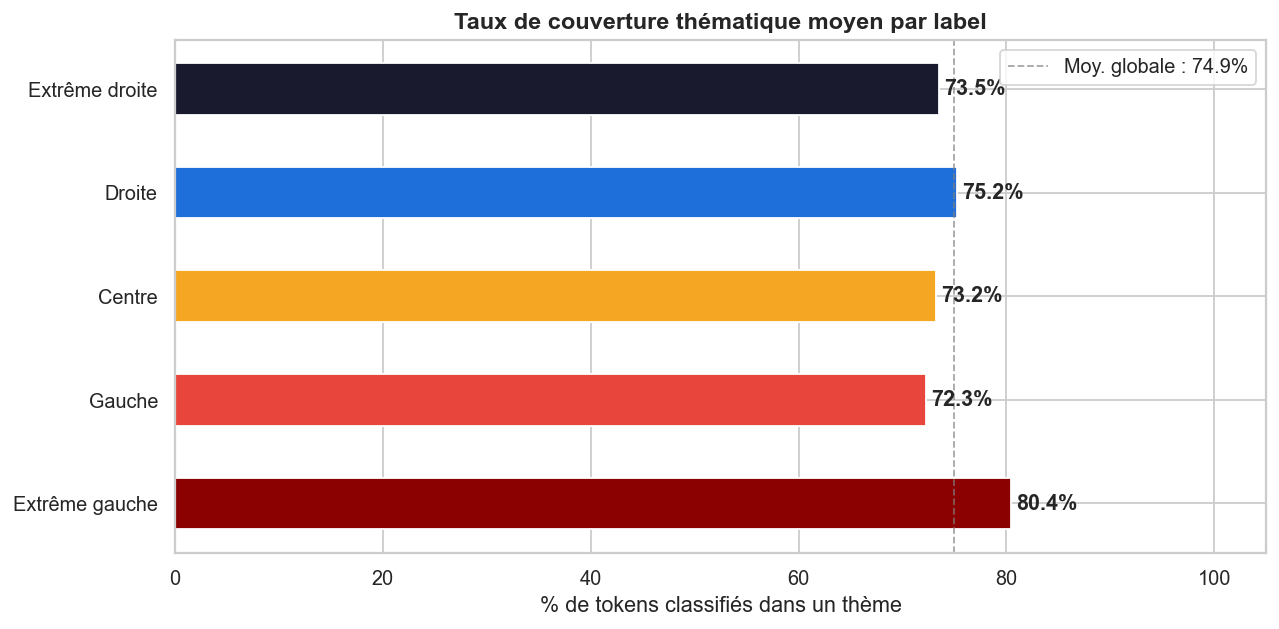

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

cov = df[df['total_tokens'] > 0].groupby('y', observed=True)['coverage_pct'].mean()
cov.index = [LABEL_NAMES[y] for y in cov.index]
cov = cov.reindex([LABEL_NAMES[y] for y in ORDER])

bars = ax.barh(cov.index, cov.values, color=[COLORS[y] for y in ORDER],
               edgecolor='white', height=0.5)

for bar, val in zip(bars, cov.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_xlim(0, 105)
ax.set_xlabel('% de tokens classifiés dans un thème')
ax.set_title('Taux de couverture thématique moyen par label', fontweight='bold', fontsize=13)
ax.axvline(x=cov.mean(), color='grey', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Moy. globale : {cov.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('figures/thematique_couverture%.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Nuages de mots par orientation politique

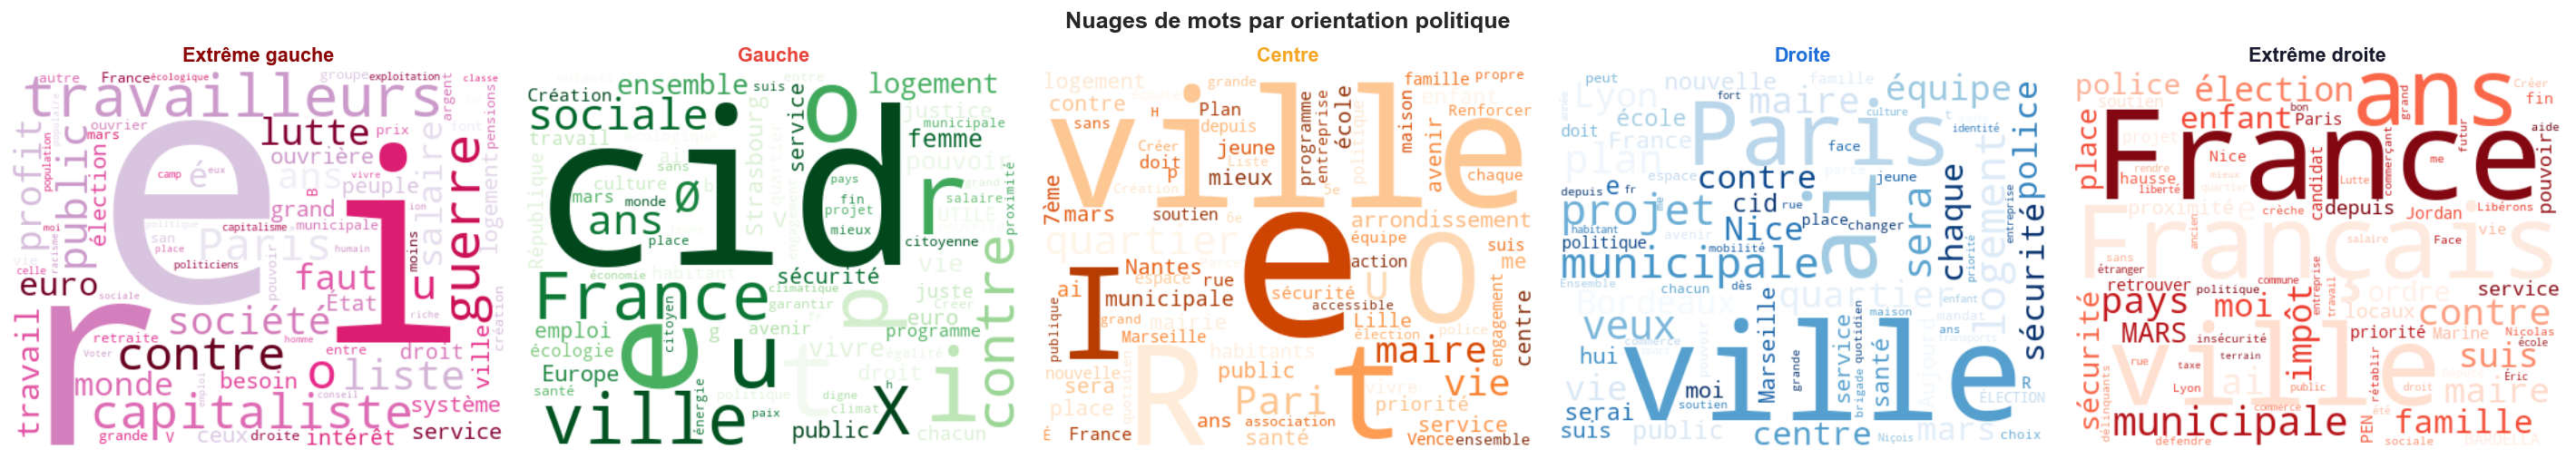

In [26]:
STOPWORDS_FR = set([
    'le','la','les','de','du','des','un','une','et','en','à','au','aux','par','pour',
    'sur','dans','qui','que','qu','il','ils','elle','elles','nous','vous','je','on',
    'ce','se','sa','son','ses','leur','leurs','mais','ou','donc','or','ni','car',
    'plus','est','sont','ont','être','avoir','avec','cette','ces','cet','tout',
    'tous','toute','toutes','notre','nos','vos','votre','y','ne','pas','si','très',
    'comme','même','aussi','bien','lors','dont','où','c','n','l','d','j','s','m',
    'a','an','fait','faire','mes','mon','ma','cette','cela','plus','après','avant'
])

CMAPS = {'ED':'Reds','D':'Blues','C':'Oranges','G':'Greens','EG':'PuRd'}

def get_text_for_label(y_code):
    docs = [d for d in all_docs if d.get('y') == y_code]
    texts = []
    for d in docs:
        for t in THEMES:
            texts.append(d.get('themes', {}).get(t, ''))
        texts.append(d.get('non_classe', ''))
    return ' '.join(texts)

fig, axes = plt.subplots(1, len(ORDER), figsize=(22, 4))

for ax, y in zip(axes, ORDER):
    text = get_text_for_label(y)
    if not text.strip():
        ax.axis('off')
        continue
    wc = WordCloud(
        width=420, height=320,
        background_color='white',
        stopwords=STOPWORDS_FR,
        colormap=CMAPS[y],
        max_words=80,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(LABEL_NAMES[y], fontweight='bold', color=COLORS[y], fontsize=12)
    ax.axis('off')

plt.suptitle('Nuages de mots par orientation politique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/nuage_de_mots.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Top 15 mots par thème (toutes orientations)

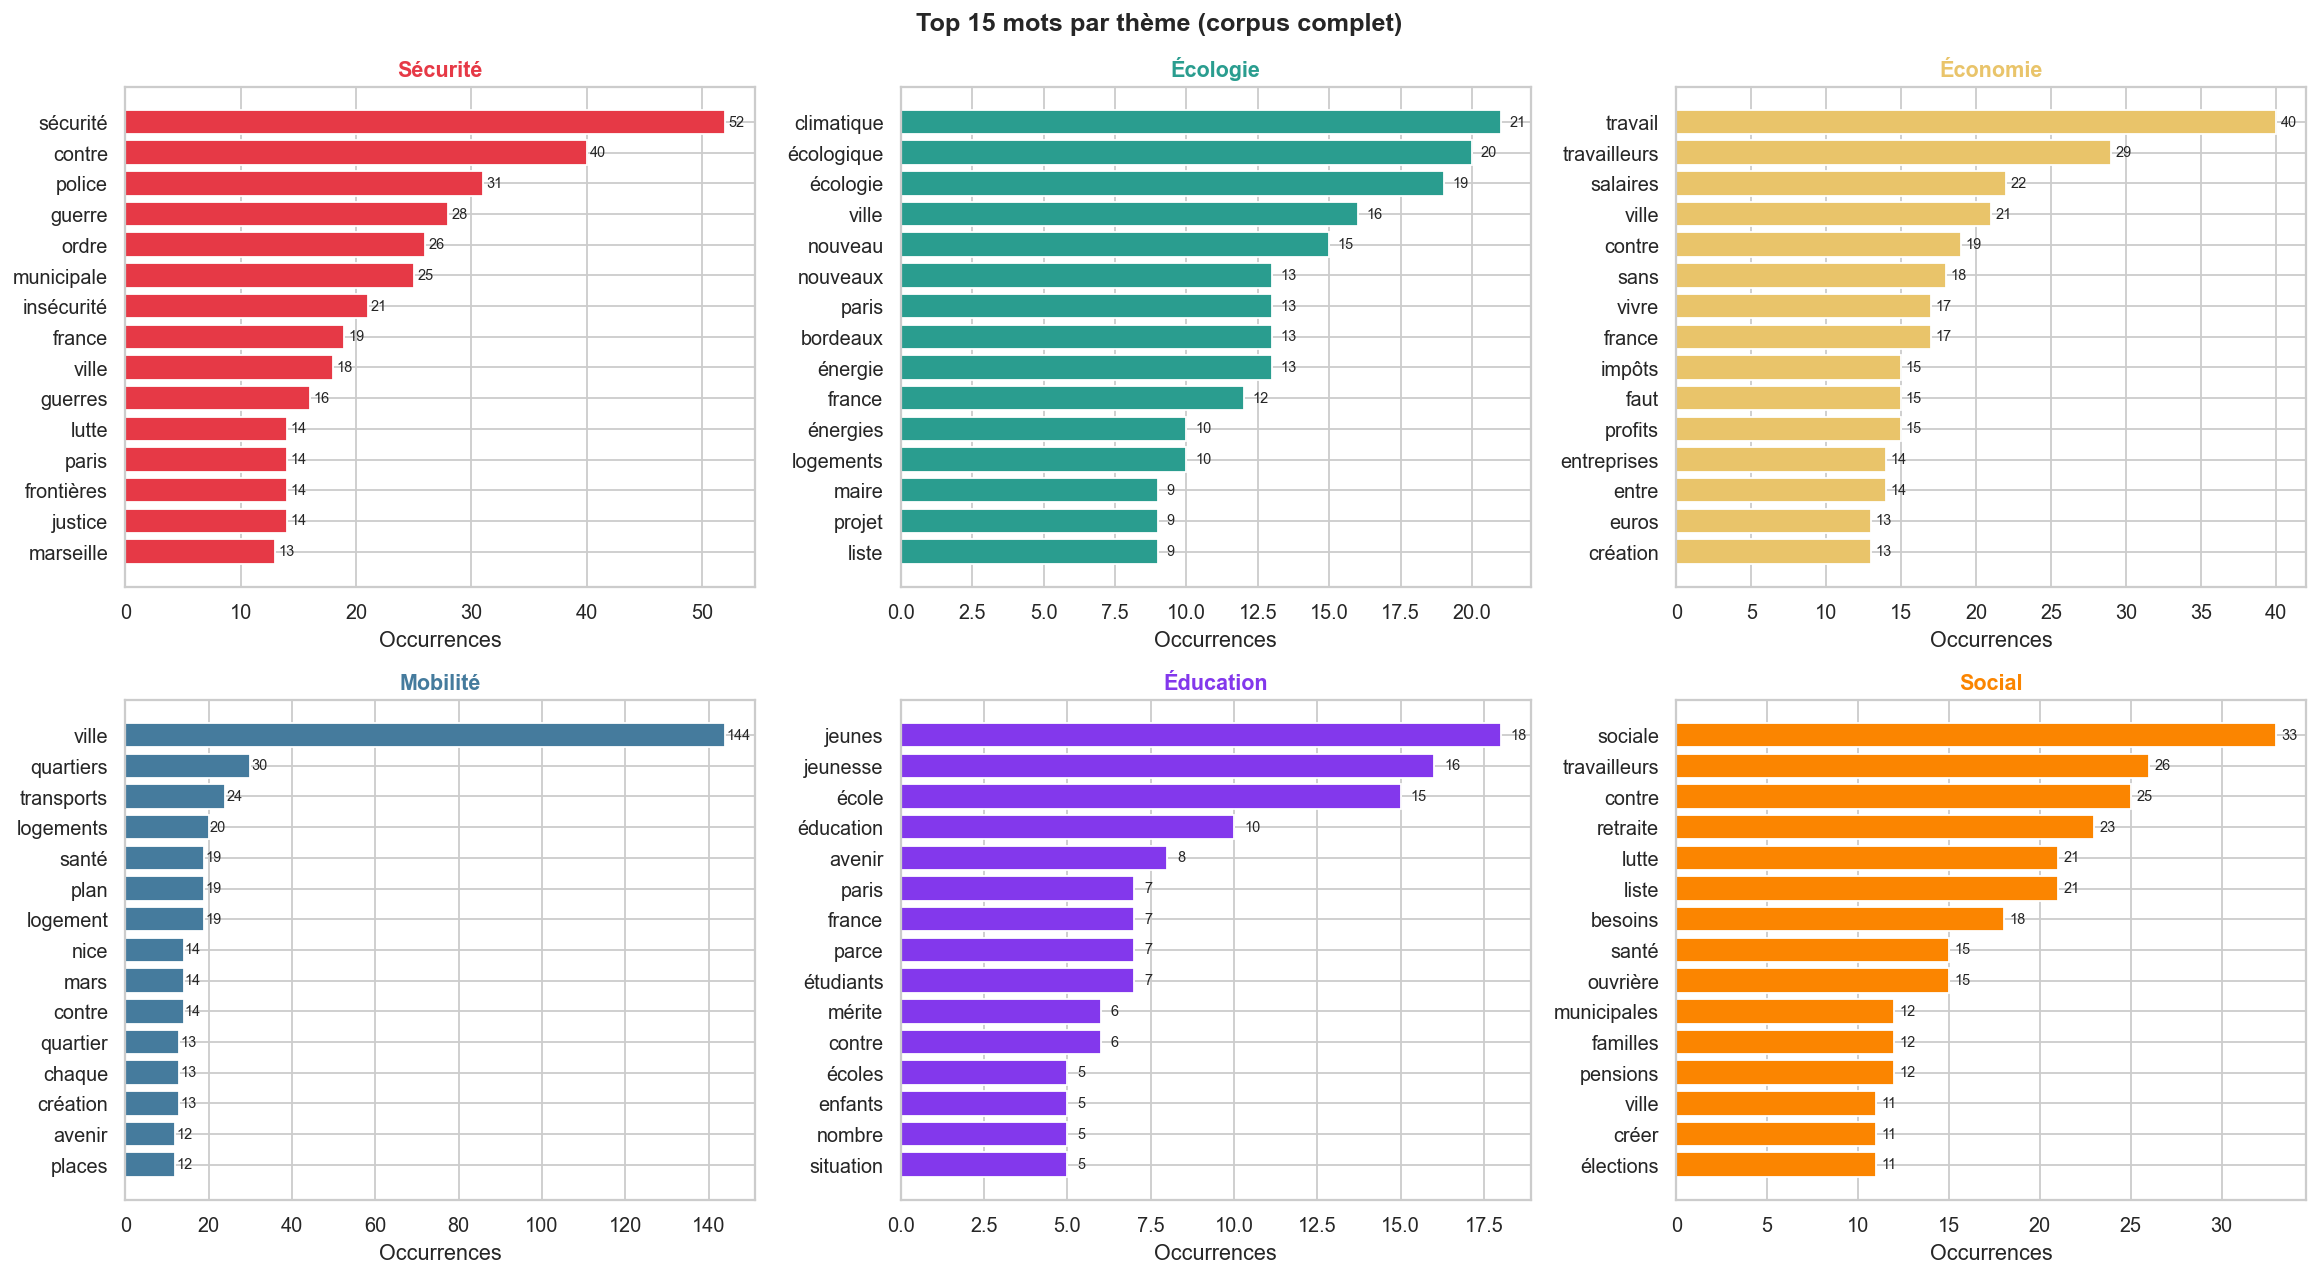

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
THEME_COLORS_MAP = dict(zip(THEMES, THEME_COLORS))

for ax, theme in zip(axes, THEMES):
    all_text = ' '.join(
        d.get('themes', {}).get(theme, '') for d in all_docs
    ).lower()
    words = [w for w in re.findall(r'[a-zàâçéèêëîïôùûü]+', all_text)
             if w not in STOPWORDS_FR and len(w) > 3]
    top = Counter(words).most_common(15)
    if not top:
        ax.axis('off')
        continue
    mots, counts = zip(*top)
    bars = ax.barh(list(reversed(mots)), list(reversed(counts)),
                   color=THEME_COLORS_MAP[theme], edgecolor='white')
    ax.set_title(f'{THEME_LABELS[theme]}', fontweight='bold', fontsize=12,
                 color=THEME_COLORS_MAP[theme])
    ax.set_xlabel('Occurrences')
    for bar, val in zip(bars, list(reversed(counts))):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.suptitle('Top 15 mots par thème (corpus complet)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/top_mots_par_theme.png', dpi=130, bbox_inches='tight')
plt.show()

## 10. Tableau récapitulatif

In [28]:
recap = df.groupby('y', observed=True).agg(
    docs=('id','count'),
    total_tokens=('total_tokens','sum'),
    moy_tokens=('total_tokens','mean'),
    coverage=('coverage_pct','mean'),
    **{THEME_LABELS[t]: (f'tokens_{t}', 'sum') for t in THEMES}
).round(1)

recap.index = [LABEL_NAMES[y] for y in recap.index]
recap.index.name = 'Label'
recap.columns = ['Docs','Total tokens','Moy tokens/doc','Coverage %'] + list(THEME_LABELS.values())
recap

,Docs,Total tokens,Moy tokens/doc,Coverage %,Sécurité,Écologie,Économie,Mobilité,Éducation,Social
Label,,,,,,,,,,
Extrême gauche,11,10571,961.0,80.4,1433,887,2568,602,345,2186
Gauche,8,10314,1289.2,72.3,757,1697,1493,1252,422,1454
Centre,12,10581,881.8,61.0,1999,964,1211,1895,873,609
Droite,10,8062,806.2,67.7,1370,798,620,2544,319,425
Extrême droite,10,7419,741.9,73.5,1952,384,945,1223,262,686
